**Note**: Feel free to use CoPilot/ChatGPT for editing/plotting your findings

In [ ]:
!pip install git+https://github.com/murtylab/comp-neuro.git

In [1]:
import torch.nn as nn
import torch
from compneuro.training import train_model
from compneuro.mlp import build_mlp_model, visualize_mlp
from compneuro.utils.video import show_video

save_dir = "results/vis/single_neuron"

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'MLP Architecture: 1 → 5 → 1'}>)

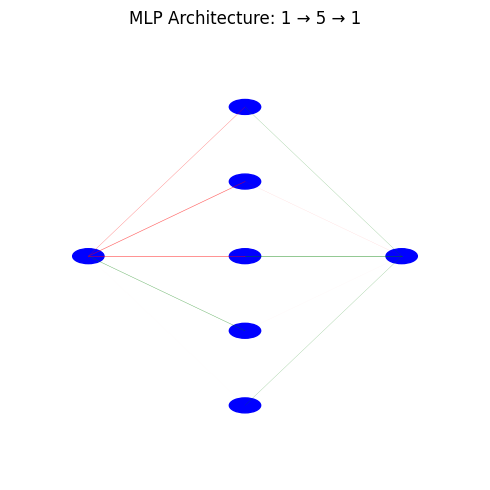

In [2]:
model = build_mlp_model(
    size_sequence=[1, 5, 1],
)
visualize_mlp(model=model, fig_width = 5, fig_height=5)

In [14]:
all_dataset_names = [
    "sine_wave",
    "line",
    # "line_through_zero",
    # "zigzag_line",
    # "x_square",
    # "wedge",
    # "elbow",
    # "sin_relu",
    # "noisy_line",
]

model = build_mlp_model(
    ## Try training a super wide but shallow network
    ## then try training a super deep (~5 layers) but narrow network
    size_sequence=[1, 5, 1], ## TASK: vary this and see it's effect on the test loss.
    bias = True,
    activation=nn.ReLU()
)

test_loss = train_model(
    model=model,
    dataset_name=all_dataset_names[0],
    dataset_noise=0.1,
    learning_rate=0.03,
    batch_size=32,
    num_epochs=200,
    num_data_points=50,
    test_data_fraction=0.3,
    visualize_every_nth_step=1,
    video_frames_folder=save_dir,
    save_video_as=f"training_{all_dataset_names[0]}.mp4",
    device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
)


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:17<00:00, 11.22it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [15]:
# for name in all_dataset_names:
show_video(filename=f"training_{all_dataset_names[0]}.mp4", width = 600)

# After playing around with the models, try to find the answers to the following questions:

1. How does depth and width of a network affect it’s performance? (plot/show results on 2 datasets and plot test loss v/s depth and test loss v/s width)
2. What happens when the learning rate is too high/low in a model? Log your results and write a blurb about what you find.